<a href="https://colab.research.google.com/github/adaryass/Financial-applications-with-Python/blob/main/Fama_et_French.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Modele Fama French

In [1]:
pip install famafrench

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.9/130.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.3/213.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.2 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [7]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

today_date = datetime.today()
year_prior = today_date - timedelta(weeks = 52)
str_today = today_date.strftime("%Y-%m-%d")
str_year_prior = year_prior.strftime("%Y-%m-%d")

In [4]:
# Habituellement, les fichiers CSV Fama-French nécessitent de sauter les 3 ou 4 premières lignes
Fama_French = pd.read_csv(
    'F-F_Research_Data_Factors_weekly.csv',
    sep=',',
    skiprows=3,      # Ajuster ce nombre si l’erreur persiste
    na_values='N/A'
)

Fama_French

,Unnamed: 0,Mkt-RF,SMB,HML,RF
0,19260702,1.58,-0.62,-0.86,0.06
1,19260710,0.37,-0.90,0.31,0.06
2,19260717,0.98,0.59,-1.44,0.06
3,19260724,-2.03,0.02,-0.17,0.06
4,19260731,3.06,-1.89,-0.85,0.06
...,...,...,...,...,...
5192,20260109,1.77,2.72,-0.09,0.08
5193,20260116,-0.39,1.63,0.71,0.08
5194,20260123,-0.43,0.61,0.02,0.08
5195,20260130,-0.17,-2.53,2.11,0.08


In [8]:
import pandas as pd

# 1. Chargement avec les bons paramètres :
# - skiprows=4 : ignore l'en-tête descriptif
# - skipfooter=2 : ignore la ligne vide et le copyright à la fin
# - engine='python' : nécessaire pour utiliser skipfooter
Fama_French = pd.read_csv('F-F_Research_Data_Factors_weekly.csv',
                          skiprows=4,
                          skipfooter=2,
                          engine='python',
                          sep=',')

# 2. Nettoyage des noms de colonnes (enlève les espaces vides)
Fama_French.columns = [c.strip() for c in Fama_French.columns]

# 3. Renommer la colonne vide ou "Unnamed: 0" en "Date"
Fama_French.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)

# 4. Conversion en datetime (Format YYYYMMDD)
Fama_French['Date'] = pd.to_datetime(Fama_French['Date'], format='%Y%m%d')

# 5. Définir la Date comme index
Fama_French.set_index('Date', inplace=True)

# 6. Division des valeurs par 100
# Puisque l'index est la date, l'opération mathématique ne s'applique qu'aux colonnes numériques
Fama_French = Fama_French / 100

# Affichage des premières lignes pour vérifier
print(Fama_French)

            Mkt-RF     SMB     HML      RF
Date                                      
1926-07-02  0.0158 -0.0062 -0.0086  0.0006
1926-07-10  0.0037 -0.0090  0.0031  0.0006
1926-07-17  0.0098  0.0059 -0.0144  0.0006
1926-07-24 -0.0203  0.0002 -0.0017  0.0006
1926-07-31  0.0306 -0.0189 -0.0085  0.0006
...            ...     ...     ...     ...
2026-01-02 -0.0113 -0.0093  0.0116  0.0008
2026-01-09  0.0177  0.0272 -0.0009  0.0008
2026-01-16 -0.0039  0.0163  0.0071  0.0008
2026-01-23 -0.0043  0.0061  0.0002  0.0008
2026-01-30 -0.0017 -0.0253  0.0211  0.0008

[5196 rows x 4 columns]


In [10]:
import statsmodels.api as sm
from datetime import datetime, timedelta

# 1. Téléchargement Apple et calcul des rendements hebdo
aapl_data = yf.download("AAPL", start=str_year_prior, end=str_today, auto_adjust=True)
# On extrait la clôture et on calcule le rendement (on nomme la série 'AAPL' pour la fusion)
aapl_returns = aapl_data['Close'].resample('W-FRI').last().pct_change().dropna()
aapl_returns.name = 'AAPL'

# 2. Fusion des données sur les dates communes
ff_subset = Fama_French.loc[str_year_prior : str_today]
df_final = pd.concat([aapl_returns, ff_subset], axis=1).dropna()

# 3. Préparation du Modèle Fama-French (3 Facteurs)
# Variable dépendante y : Excès de rendement de l'action
y = df_final['AAPL'] - df_final['RF']

# Variables explicatives X : Marché, Taille (SMB), Valeur (HML)
X = df_final[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X) # Ajout de l'Alpha (Constante)

# 4. Exécution de la régression OLS
model = sm.OLS(y, X).fit()

# 5. Affichage des résultats ciblés
print()
print(f"--- Modèle Fama-French (Période: {str_year_prior} à {str_today}) ---")
print(model.summary())

# Extraction spécifique des Betas
results_df = pd.DataFrame({ "beta": model.params, "t_stat": model.tvalues, "p_value": model.pvalues })

# Extraction spécifique des Betas
print("\n--- Coefficients (Betas) ---")
print(f"Beta Marché (Mkt-RF) : {model.params['Mkt-RF']:.4f}")
print(f"Beta Taille (SMB)     : {model.params['SMB']:.4f}")
print(f"Beta Valeur (HML)     : {model.params['HML']:.4f}")
print(f"Alpha (Constante)     : {model.params['const']:.4f}")

[*********************100%***********************]  1 of 1 completed


--- Modèle Fama-French (Période: 2025-03-15 à 2026-03-14) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     15.66
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           7.75e-07
Time:                        17:07:19   Log-Likelihood:                 91.567
No. Observations:                  43   AIC:                            -175.1
Df Residuals:                      39   BIC:                            -168.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [11]:
results_df = pd.DataFrame({ "beta": model.params, "t_stat": model.tvalues, "p_value": model.pvalues })
# Add adjusted R-squared as a separate row
results_df.loc["Adj_R2", "beta"] = model.rsquared_adj
results_df

,beta,t_stat,p_value
const,-0.002963,-0.632082,5.310214e-01
Mkt-RF,1.386086,6.760613,4.575181e-08
SMB,-0.377067,-1.009693,3.188662e-01
HML,0.553627,1.586561,1.206879e-01
Adj_R2,0.511441,NaN,NaN


# Fama et French pour un portefeuille

In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

/tmp/ipykernel_182/1870571229.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_182/1870571229.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_182/1870571229.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_182/1870571229.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True


<function matplotlib.pyplot.show(close=None, block=None)>

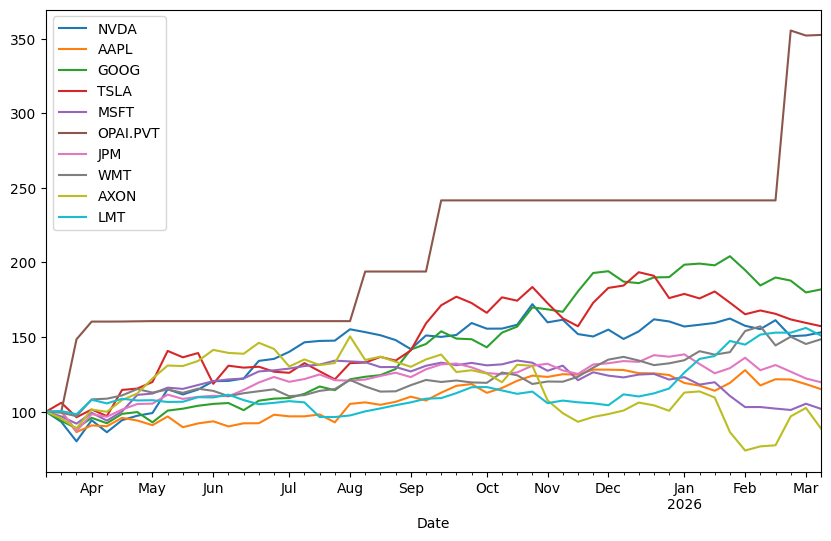

In [14]:
# choosing stock list
list_tickers = ['NVDA', 'AAPL', 'GOOG','TSLA','MSFT','OPAI.PVT', 'JPM', 'WMT', 'AXON', 'LMT']
ptf_assets = pd.DataFrame()
today_date = datetime.today()
year_prior = today_date - timedelta(weeks = 52)
str_today = today_date.strftime("%Y-%m-%d")
str_year_prior = year_prior.strftime("%Y-%m-%d")

#download prices
for ticker in list_tickers:
       ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
(ptf_assets/ptf_assets.iloc[0] * 100).plot(figsize = (10,6))
plt.show

In [25]:
import statsmodels.api as sm

# 1. Calcul des rendements hebdomadaires des actifs
# Rééchantillonner ptf_assets en 'W-FRI' pour aligner son index avec celui de Fama_French
# Cela garantit que lors de la concaténation, les dates correspondent et que dropna() ne crée pas un DataFrame vide.
ptf_assets_resampled = ptf_assets.resample('W-FRI').last()
asset_returns = ptf_assets_resampled.pct_change().dropna()

# 2. Construction du portefeuille équipondéré
n_assets = len(asset_returns.columns)
weights = np.repeat(1/n_assets, n_assets)

portfolio_returns = asset_returns.dot(weights)
portfolio_returns.name = 'PORTFOLIO'

# 3. Fusion avec les facteurs Fama-French
ff_subset = Fama_French.loc[str_year_prior:str_today]
df_final = pd.concat([portfolio_returns, ff_subset], axis=1).dropna()

# 4. Variable dépendante : excès de rendement du portefeuille
y = df_final['PORTFOLIO'] - df_final['RF']

# 5. Variables explicatives
X = df_final[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)

# 6. Régression OLS
model = sm.OLS(y, X).fit()

print()
print(f"--- Modèle Fama-French pour le portefeuille (Période: {str_year_prior} à {str_today}) ---")
print(model.summary())

# Tableau des coefficients
results_df = pd.DataFrame({
    "beta": model.params,
    "t_stat": model.tvalues,
    "p_value": model.pvalues
})

print("\n--- Coefficients du portefeuille ---")
print(results_df)


--- Modèle Fama-French pour le portefeuille (Période: 2025-03-15 à 2026-03-14) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     36.86
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.82e-11
Time:                        17:45:13   Log-Likelihood:                 123.97
No. Observations:                  43   AIC:                            -239.9
Df Residuals:                      39   BIC:                            -232.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------